# 데이터 시각화 미니 퀘스트

In [2]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib_venn import venn2
import seaborn as sns
import scipy.stats as stats

## 정형 데이터 - 미니 퀘스트

### 1번 퀘스트
샘플 데이터프레임을 생성한 후, 데이터의 기본 정보를 출력하는 코드를 작성하세요.

In [3]:
# 샘플 데이터 생성
data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동'],
    '나이': [25, 30, 35, 28, 40],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO'],
    '연봉': [4000, 3500, 5000, 4200, 10000],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27']
}

df = pd.DataFrame(data)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   이름      5 non-null      str  
 1   나이      5 non-null      int64
 2   직업      5 non-null      str  
 3   연봉      5 non-null      int64
 4   가입일     5 non-null      str  
dtypes: int64(2), str(3)
memory usage: 332.0 bytes


### 2번 퀘스트
샘플 데이터에서 나이가 30 이상이고 연봉이 5000 이하인 사람들만 필터링하는 코드를 작성하세요.

In [4]:
# 샘플 데이터 생성
data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동', '정지훈', '이지은'],
    '나이': [25, 30, 35, 28, 40, 50, 22],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO', '디자이너', '마케터'],
    '연봉': [4000, 3500, 5000, 4200, 10000, 4600, 3300],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27', '2016-04-11', '2022-03-19']
}

df = pd.DataFrame(data)
df[(df["나이"] >= 30) & (df["연봉"] <= 5000)]

,이름,나이,직업,연봉,가입일
1,이영희,30,마케터,3500,2019-07-15
2,박민수,35,개발자,5000,2021-01-10
5,정지훈,50,디자이너,4600,2016-04-11


### 3번 퀘스트
샘플 데이터에서 가입 연도가 2019년 이전인 사람들을 찾아 연봉을 10% 인상한 후, 전체 평균 연봉을 계산하는 코드를 작성하세요.

In [5]:
# 샘플 데이터 생성
data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동', '정지훈', '이지은'],
    '나이': [25, 30, 35, 28, 40, 50, 22],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO', '디자이너', '마케터'],
    '연봉': [4000, 3500, 5000, 4200, 10000, 4600, 3300],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27', '2016-04-11', '2022-03-19']
}

df = pd.DataFrame(data)
df["가입일"] = pd.to_datetime(df["가입일"])
df["연봉"] = df["연봉"].astype(float)
df.loc[df["가입일"].dt.year <= 2019, "연봉"] *= 1.1
df

,이름,나이,직업,연봉,가입일
0,김철수,25,개발자,4000.0,2020-05-21
1,이영희,30,마케터,3850.0,2019-07-15
2,박민수,35,개발자,5000.0,2021-01-10
3,최지현,28,디자이너,4620.0,2018-11-03
4,홍길동,40,CEO,11000.0,2017-09-27
5,정지훈,50,디자이너,5060.0,2016-04-11
6,이지은,22,마케터,3300.0,2022-03-19


## 비정형 데이터 - 미니 퀘스트

### 1번 퀘스트
JSON 형식의 데이터를 직접 생성한 후, Pandas 데이터프레임으로 변환하는 코드를 작성하세요.

In [6]:
# JSON 데이터 직접 생성
data = '''
[
    {"이름": "김철수", "나이": 25, "직업": "개발자", "연봉": 4000},
    {"이름": "이영희", "나이": 30, "직업": "마케터", "연봉": 3500},
    {"이름": "박민수", "나이": 35, "직업": "디자이너", "연봉": 4200}
]
'''

parsed_data = json.loads(data)
df = pd.DataFrame(parsed_data)
df

,이름,나이,직업,연봉
0,김철수,25,개발자,4000
1,이영희,30,마케터,3500
2,박민수,35,디자이너,4200


### 2번 퀘스트
아래 샘플 데이터에서 한글과 공백을 제외한 모든 문자를 제거하고, 공백을 하나로 정리하는 코드를 작성하세요.

In [7]:
# 샘플 데이터 생성
text = "안녕하세요!!! 저는 AI 모델-입니다. 12345 데이터를   정리해 보겠습니다."

clean_text = re.sub(r"[^가-힣\s]", "", text)
clean_text = re.sub(r"\s+", " ", clean_text).strip()

clean_text

'안녕하세요 저는 모델입니다 데이터를 정리해 보겠습니다'

### 3번 퀘스트
주어진 텍스트 데이터를 문장 단위로 분리한 후, 각 문장의 단어 개수를 데이터프레임으로 변환하는 코드를 작성하세요.

In [8]:
# 샘플 텍스트 데이터
text = "자연어 처리는 재미있다. 파이썬과 pandas를 활용하면 편리하다. 데이터 분석은 흥미롭다."

sentences = text.split(".")
sentences.pop()
df = pd.DataFrame()
for i, sentence in enumerate(sentences):
    df.loc[i, "#words"] = len(sentence.strip().split())
df

,#words
0,3.0
1,4.0
2,3.0


## 막대 그래프 - 미니 퀘스트

### 1번 퀘스트
matplotlib을 활용하여 5개의 카테고리와 각각의 값이 포함된 기본 세로 막대 그래프를 생성하는 코드를 작성하세요.

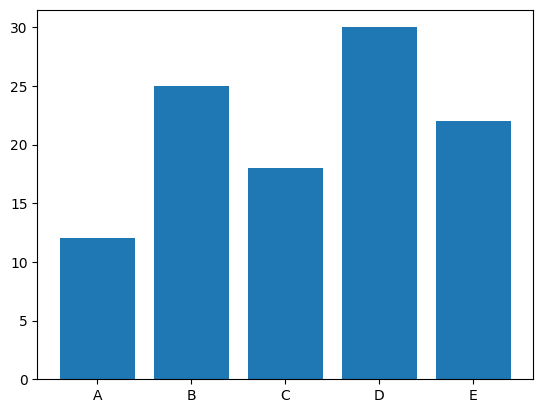

In [9]:
# 샘플 데이터 생성
categories = ['A', 'B', 'C', 'D', 'E']
values = [12, 25, 18, 30, 22]

plt.bar(categories, values)
plt.show()

### 2번 퀘스트
누적형 막대 그래프를 생성하여, 두 개의 연도별 데이터를 각각 다른 색상으로 누적하여 표현하는 코드를 작성하세요.

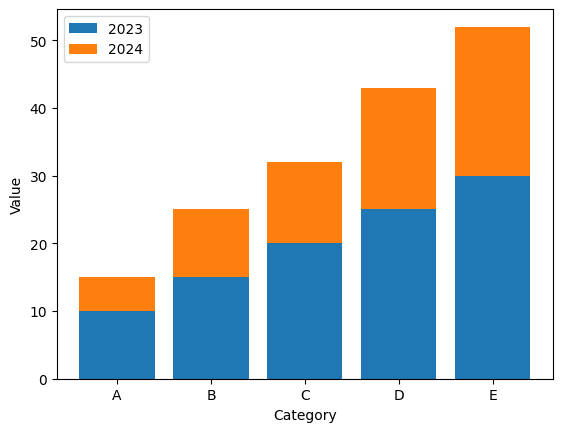

In [10]:
# 샘플 데이터 생성
categories = ['A', 'B', 'C', 'D', 'E']
values_2023 = [10, 15, 20, 25, 30]
values_2024 = [5, 10, 12, 18, 22]

plt.bar(categories, values_2023, label='2023')
plt.bar(categories, values_2024, label='2024', bottom=values_2023)

plt.legend()
plt.xlabel("Category")
plt.ylabel("Value")

plt.show()

### 3번 퀘스트
한 기업의 부서별 연간 성과(2023년 vs 2024년)를 비교하는 그룹형 막대 그래프를 생성하는 코드를 작성하세요.

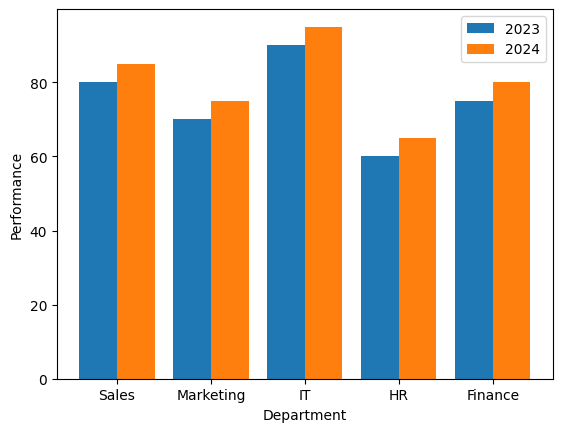

In [11]:
# 샘플 데이터 생성
departments = ['Sales', 'Marketing', 'IT', 'HR', 'Finance']
performance_2023 = [80, 70, 90, 60, 75]
performance_2024 = [85, 75, 95, 65, 80]

bar_width = .4
x = np.arange(len(departments))
plt.bar(x - bar_width / 2, performance_2023, width=bar_width, label='2023')
plt.bar(x + bar_width / 2, performance_2024, width=bar_width, label='2024')

plt.legend()
plt.xticks(x, departments)
plt.xlabel("Department")
plt.ylabel("Performance")

plt.show()

## 히스토그램 - 미니 퀘스트

### 1번 퀘스트
정규 분포를 따르는 1000개의 데이터를 생성한 후, 구간을 15개로 설정한 히스토그램을 그리는 코드를 작성하세요.

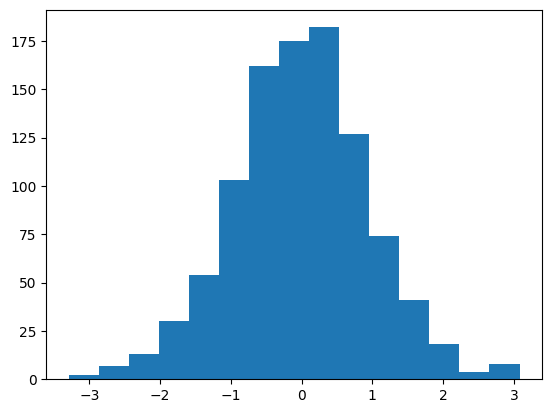

In [12]:
# 정규 분포를 따르는 1000개의 데이터 생성
data = np.random.randn(1000)

plt.hist(data, bins=15)
plt.show()

### 2번 퀘스트
두 개의 서로 다른 정규 분포를 따르는 데이터셋을 생성한 후, 두 히스토그램을 같은 그래프에서 겹쳐서 비교하는 코드를 작성하세요.

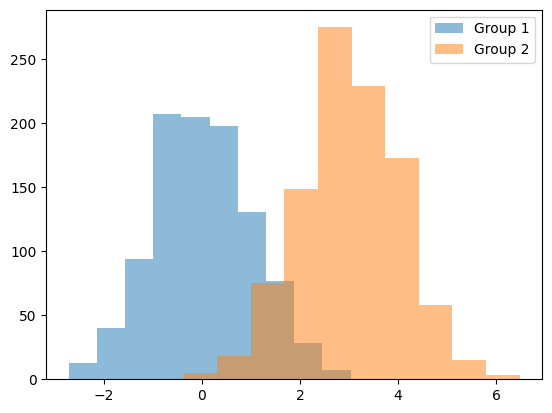

In [13]:
# 첫 번째 데이터셋 (평균 0, 표준편차 1)
data1 = np.random.randn(1000)
# 두 번째 데이터셋 (평균 3, 표준편차 1)
data2 = np.random.randn(1000) + 3

plt.hist(data1, alpha=.5, label='Group 1')
plt.hist(data2, alpha=.5, label='Group 2')

plt.legend()

plt.show()

### 3번 퀘스트
한 데이터셋의 누적 히스토그램을 그린 후, X축과 Y축의 적절한 레이블을 설정하는 코드를 작성하세요.

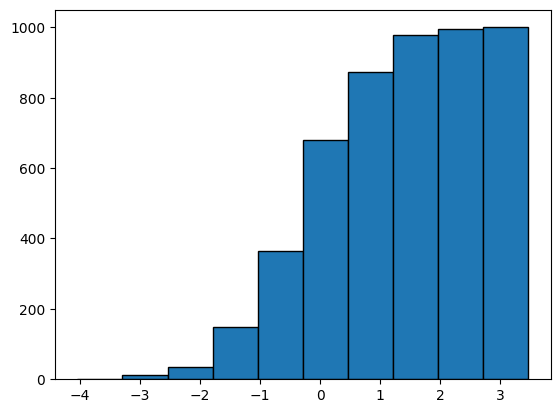

In [14]:
# 정규 분포를 따르는 1000개의 데이터 생성
data = np.random.randn(1000)

plt.hist(data, cumulative=True, edgecolor='black')
plt.show()

## 산점도 - 미니 퀘스트

### 1번 퀘스트
두 개의 리스트 `x = [1, 2, 3, 4, 5]`, `y = [3, 1, 4, 5, 2]`를 사용하여 산점도를 그리고, X축과 Y축의 라벨을 추가하는 코드를 작성하세요.

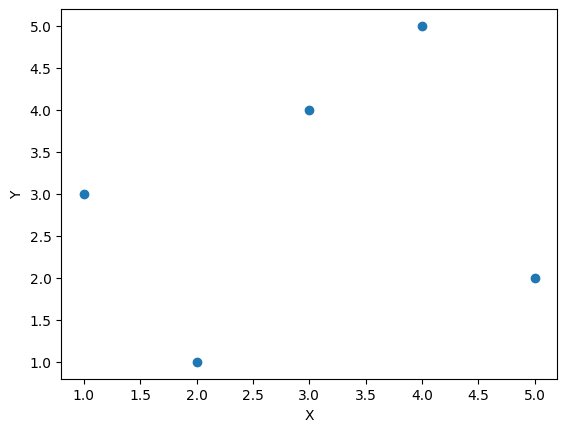

In [15]:
# 데이터 생성
x = [1, 2, 3, 4, 5]
y = [3, 1, 4, 5, 2]

plt.scatter(x, y)

plt.xlabel("X")
plt.ylabel("Y")

plt.show()

### 2번 퀘스트
`numpy`를 활용하여 난수를 생성한 후, 산점도를 그리고 점의 색상과 투명도를 설정하는 코드를 작성하세요.

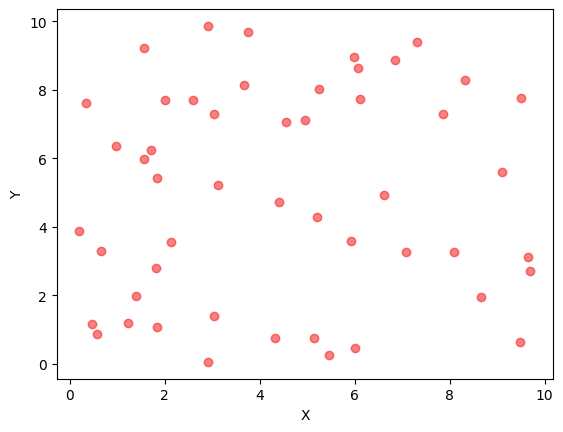

In [16]:
# 난수 데이터 생성
np.random.seed(42)
x = np.random.rand(50) * 10  # 0~10 범위의 난수 50개
y = np.random.rand(50) * 10  # 0~10 범위의 난수 50개

plt.scatter(x, y, alpha=.5, color="red")

plt.xlabel("X")
plt.ylabel("Y")

plt.show()

### 3번 퀘스트
`numpy`를 활용하여 세 개의 그룹('A', 'B', 'C')에 속하는 데이터의 산점도를 서로 다른 색상으로 그리는 코드를 작성하세요.

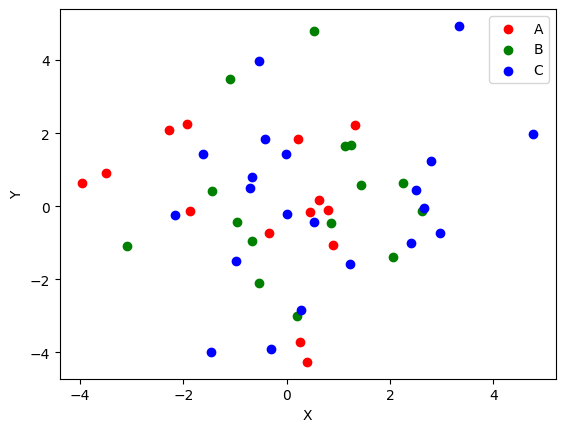

In [17]:
# 데이터 생성
np.random.seed(10)
x = np.random.randn(50) * 2
y = np.random.randn(50) * 2
categories = np.random.choice(['A', 'B', 'C'], size=50)

colors = {"A": "red", "B": "green", "C": "blue"}
for cat in np.unique(categories):
    idx = categories == cat
    plt.scatter(x[idx], y[idx], color=colors[cat], label=cat)

plt.xlabel("X")
plt.ylabel("Y")
plt.legend()

plt.show()

## 박스플롯 - 미니 퀘스트

### 1번 퀘스트
평균 0, 표준편차 1을 따르는 정규분포 난수 50개를 생성한 후, 해당 데이터를 이용해 기본 박스 플롯을 출력하는 코드를 작성하세요.

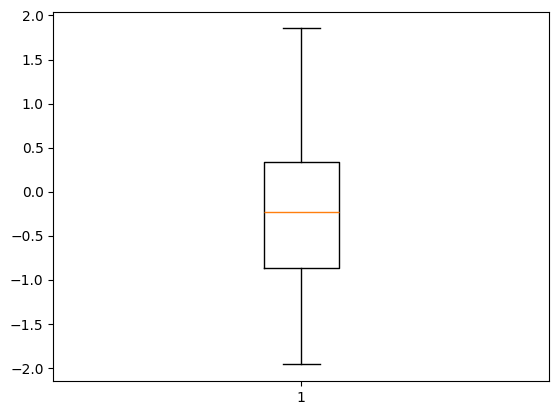

In [18]:
# 정규분포를 따르는 난수 50개 생성
np.random.seed(42)
data = np.random.randn(50)

plt.boxplot(data)

plt.show()

### 2번 퀘스트
세 개의 그룹(Group A, Group B, Group C) 에 대해 각각 다른 평균을 가지는 데이터를 생성하고, 이를 이용해 다중 박스 플롯을 그리는 코드를 작성하세요.

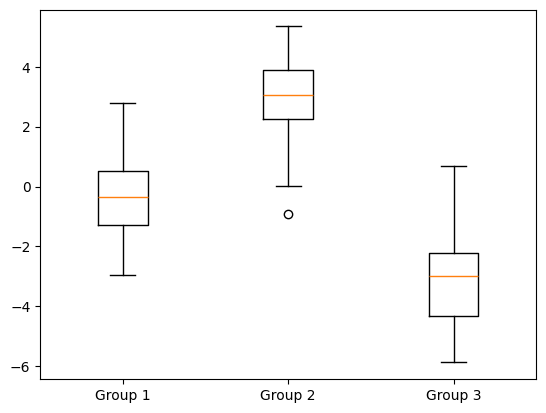

In [19]:
# 랜덤 데이터 생성 (각 그룹별 평균 다르게 설정)
np.random.seed(42)
group_a = np.random.randn(50) * 1.5  # 표준편차 1.5, 평균 0
group_b = np.random.randn(50) * 1.5 + 3  # 표준편차 1.5, 평균 3
group_c = np.random.randn(50) * 1.5 - 3  # 표준편차 1.5, 평균 -3

plt.boxplot([group_a, group_b, group_c], tick_labels=["Group 1", "Group 2", "Group 3"])

plt.show()

### 3번 퀘스트
평균이 **서로 다른 두 개의 그룹(Group X, Group Y)** 을 비교하는 박스 플롯을 그리세요.

단, **이상값을 강조하고, 스타일을 커스터마이징**해야 합니다.

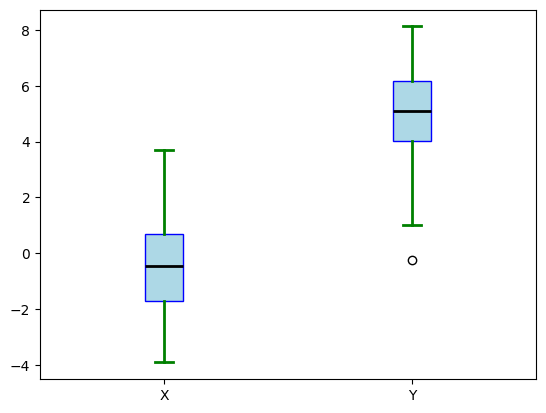

In [20]:
# 랜덤 데이터 생성 (두 그룹의 평균 다르게 설정)
np.random.seed(42)
group_x = np.random.randn(50) * 2  # 표준편차 2, 평균 0
group_y = np.random.randn(50) * 2 + 5  # 표준편차 2, 평균 5

plt.boxplot(
    [group_x, group_y],
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="blue"),
    whiskerprops=dict(color="green", linewidth=2),
    capprops=dict(color="green", linewidth=2),
    medianprops=dict(color="black", linewidth=2)
)

plt.xticks(range(1, 3), ["X", "Y"])

plt.show()

## 고급 다중 그래프 - 미니 퀘스트

### 1번 퀘스트
plt.subplots()를 사용하여 2x1 형태의 서브플롯을 만들고, 첫 번째 서브플롯에는 y = x^2, 두 번째 서브플롯에는 y = x^3을 그리는 코드를 작성하세요.

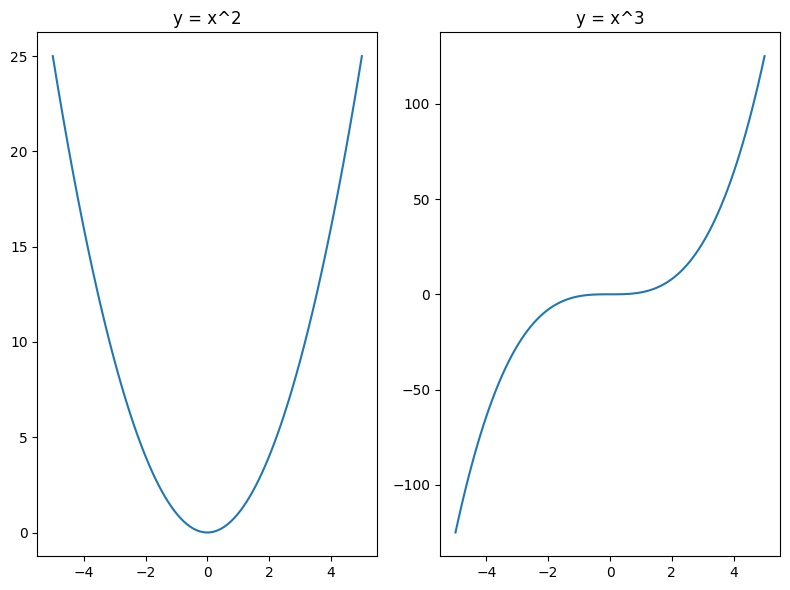

In [21]:
# 데이터 생성
x = np.linspace(-5, 5, 100)
y1 = x ** 2  # x의 제곱
y2 = x ** 3  # x의 세제곱

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 6))

axes[0].plot(x, y1, label='x^2')
axes[0].set_title("y = x^2")
axes[1].plot(x, y2, label='x^3')
axes[1].set_title("y = x^3")

plt.tight_layout()

plt.show()

### 2번 퀘스트
X축을 공유하는 1행 2열 형태의 서브플롯을 생성하고, 첫 번째 서브플롯에는 정규 분포를 따르는 난수의 히스토그램, 두 번째 서브플롯에는 균등 분포를 따르는 난수의 히스토그램을 그리세요.

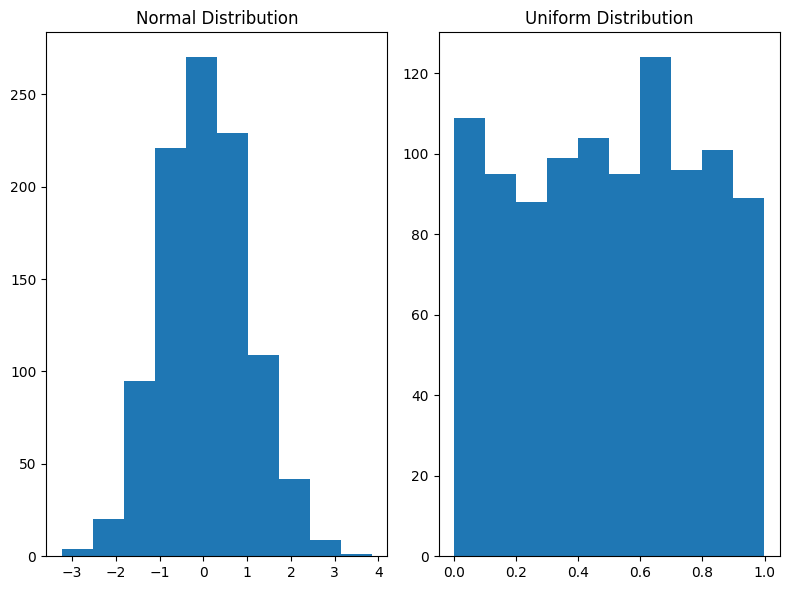

In [22]:
# 데이터 생성
normal_data = np.random.randn(1000)  # 정규 분포 난수 1000개
uniform_data = np.random.rand(1000)  # 균등 분포 난수 1000개

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 6))

axes[0].hist(normal_data)
axes[0].set_title("Normal Distribution")
axes[1].hist(uniform_data)
axes[1].set_title("Uniform Distribution")

plt.tight_layout()

plt.show()

### 3번 퀘스트
`gridspec`을 사용하여 불규칙한 레이아웃의 서브플롯을 생성하고, 각각 선 그래프, 산점도, 막대 그래프, 히스토그램을 그리세요.

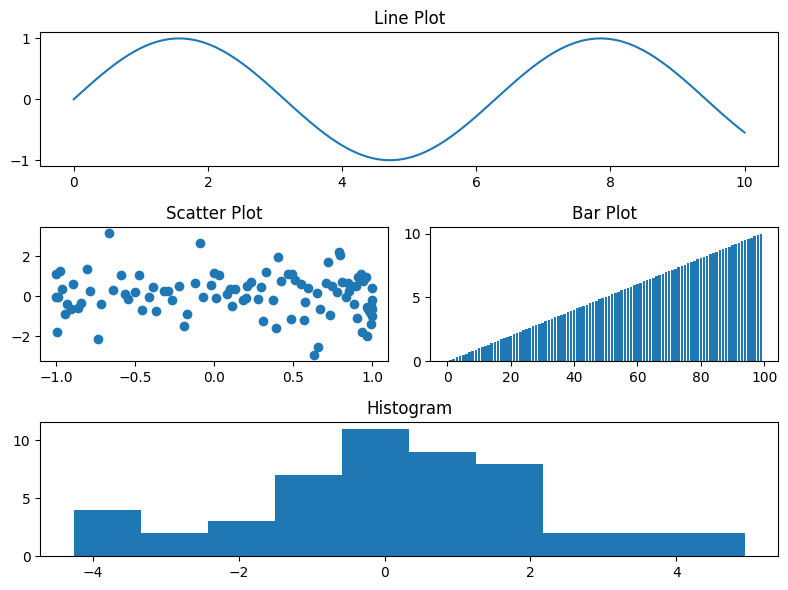

In [23]:
# 데이터 생성
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.random.randn(100)
categories = ['A', 'B', 'C', 'D', 'E']
values = [3, 7, 5, 2, 8]

fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(3, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(x, y1)
ax1.set_title("Line Plot")

ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(y1, y2)
ax2.set_title("Scatter Plot")

ax3 = fig.add_subplot(gs[1, 1])
ax3.bar(range(len(x)), x)
ax3.set_title("Bar Plot")

ax4 = fig.add_subplot(gs[2, :])
ax4.hist(y)
ax4.set_title("Histogram")

plt.tight_layout()

## 벤 다이어그램 - 미니 퀘스트

### 1번 퀘스트
두 개의 과일 집합을 정의하고, 두 집합의 차집합(한 집합에만 존재하는 요소)을 출력하는 코드를 작성하세요.

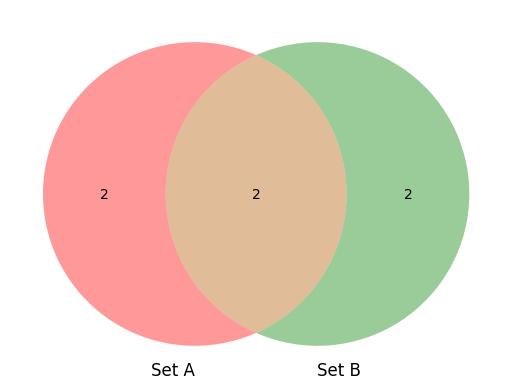

In [24]:
# 두 개의 과일 집합 정의
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}

venn2([set_A, set_B], set_labels=("Set A", "Set B"))

plt.show()

### 2번 퀘스트
벤 다이어그램을 그리지 않고, 세 개의 집합을 비교하여 각 집합이 단독으로 가지는 요소 개수와 교집합 개수를 계산하는 코드를 작성하세요.

In [25]:
# 세 개의 과일 집합 정의
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}
set_C = {"망고", "수박", "딸기", "오렌지"}

union_A_B = set_A & set_B
union_B_C = set_B & set_C
union_C_A = set_C & set_A

print("A")
print(f"단독으로 가지는 요소의 개수: {len(set_A) - len(union_A_B | union_C_A)}")
print(f"교집합의 개수: {len(union_A_B | union_C_A)}")

A
단독으로 가지는 요소의 개수: 2
교집합의 개수: 2


In [26]:
print("B")
print(f"단독으로 가지는 요소의 개수: {len(set_B) - len(union_A_B | union_B_C)}")
print(f"교집합의 개수: {len(union_A_B | union_B_C)}")

B
단독으로 가지는 요소의 개수: 1
교집합의 개수: 3


In [27]:
print("C")
print(f"단독으로 가지는 요소의 개수: {len(set_C) - len(union_B_C | union_C_A)}")
print(f"교집합의 개수: {len(union_B_C | union_C_A)}")

C
단독으로 가지는 요소의 개수: 2
교집합의 개수: 2


### 3번 퀘스트
벤 다이어그램을 그리면서, 특정 조건을 만족하는 경우 색상을 다르게 지정하는 코드를 작성하세요.
- 조건: 두 개의 집합을 비교할 때, 교집합이 2개 이상이면 노란색, 그렇지 않으면 기본 색상을 사용하세요.

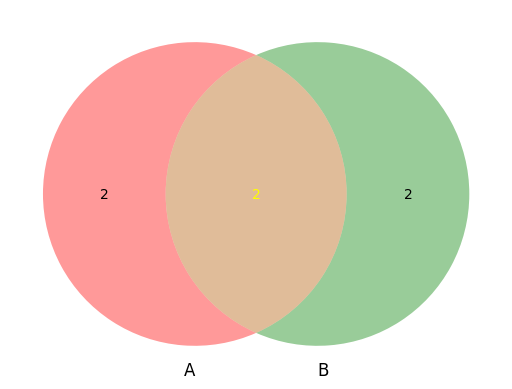

In [28]:
# 두 개의 집합 정의
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}

diagram = venn2(subsets=[set_A, set_B])

diagram.get_label_by_id("11").set_color("yellow")

## 범주형 데이터 - 미니 퀘스트

### 1번 퀘스트
샘플 데이터를 직접 생성한 후 Seaborn을 활용하여 막대 그래프(bar plot)를 생성하는 코드를 작성하세요.

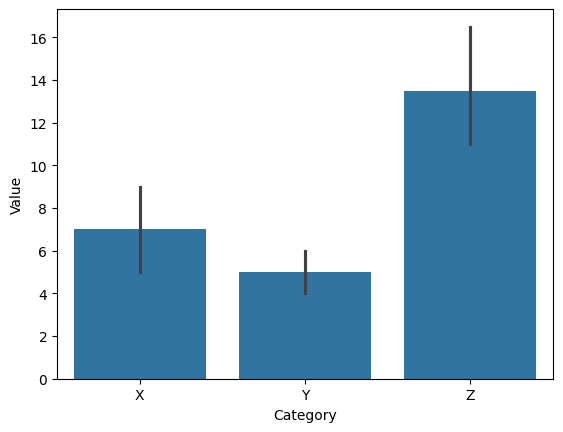

In [29]:
# 샘플 데이터 생성
data = pd.DataFrame({
    "Category": ["X", "X", "Y", "Y", "Z", "Z", "Z", "X", "Y", "Z"],
    "Value": [5, 9, 4, 6, 12, 10, 14, 7, 5, 18]
})

sns.barplot(data, x="Category", y="Value")

plt.show()

### 2번 퀘스트
Seaborn의 `sns.boxplot()`을 활용하여 범주형 데이터의 분포를 시각화하는 코드를 작성하세요.

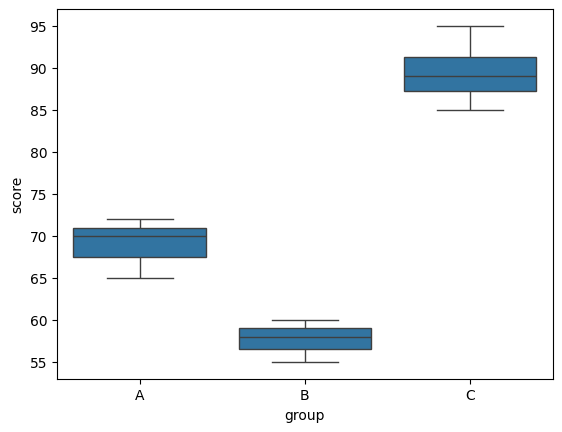

In [30]:
# 샘플 데이터 생성
data = pd.DataFrame({
    "group": ["A", "A", "B", "B", "C", "C", "C", "A", "B", "C"],
    "score": [65, 70, 55, 60, 90, 85, 95, 72, 58, 88]
})

sns.boxplot(data, x="group", y="score")

plt.show()

### 3번 퀘스트
Seaborn의 `sns.violinplot()`과 `sns.stripplot()`을 함께 사용하여 범주형 데이터의 분포를 더욱 자세히 시각화하는 코드를 작성하세요.

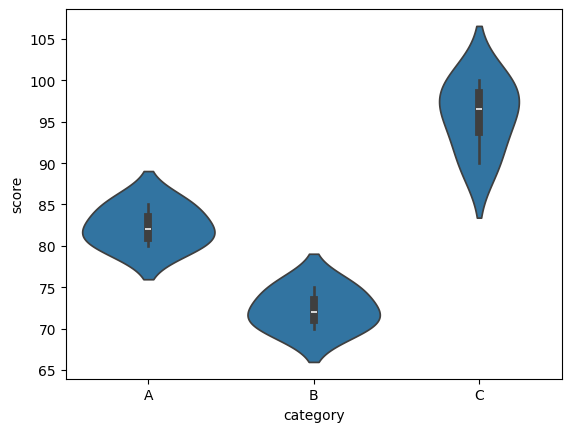

In [31]:
# 샘플 데이터 생성
data = pd.DataFrame({
    "category": ["A", "A", "B", "B", "C", "C", "C", "A", "B", "C"],
    "score": [80, 85, 70, 75, 95, 90, 100, 82, 72, 98]
})

sns.violinplot(data=data, x="category", y="score")

plt.show()

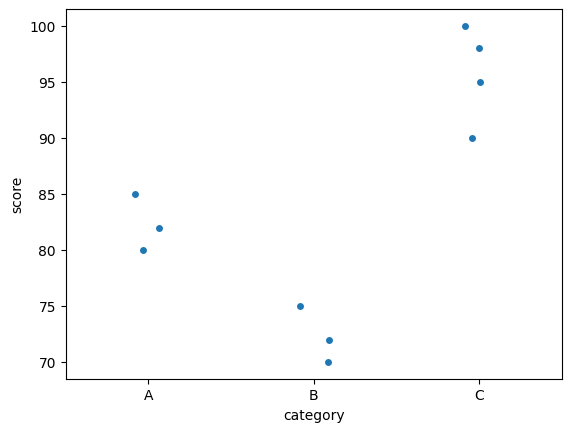

In [32]:
sns.stripplot(data=data, x="category", y="score")

plt.show()


## 연속형 데이터 - 미니 퀘스트

### 1번 퀘스트
평균 0, 표준편차 1을 따르는 정규 분포 데이터를 500개 생성한 후, 히스토그램과 KDE를 함께 시각화하는 코드를 작성하세요.

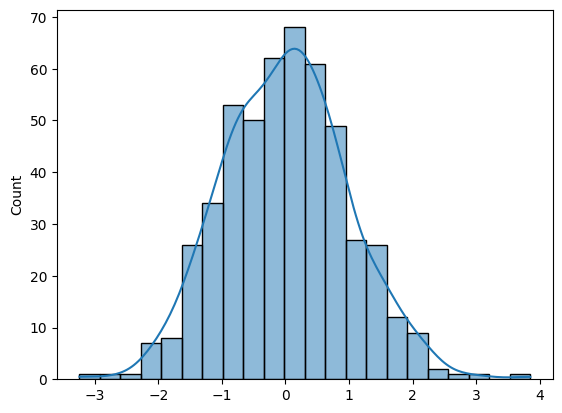

In [33]:
# 정규 분포를 따르는 데이터 생성
np.random.seed(42)
data = np.random.randn(500)

sns.histplot(data, kde=True)

plt.show()

### 2번 퀘스트
0부터 20까지 균등한 간격으로 생성된 데이터를 사용하여, 사인 함수의 선 그래프를 그리는 코드를 작성하세요.

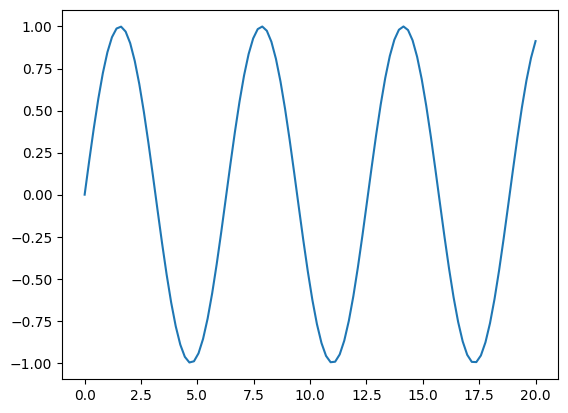

In [34]:
# X 값 생성 (0부터 20까지 100개의 균등한 값)
x = np.linspace(0, 20, 100)
y = np.sin(x)

sns.lineplot(x=x, y=y)

plt.show()

### 3번 퀘스트
랜덤한 100개의 연속형 데이터를 생성하여, 산점도와 회귀선을 포함한 그래프를 그리는 코드를 작성하세요.

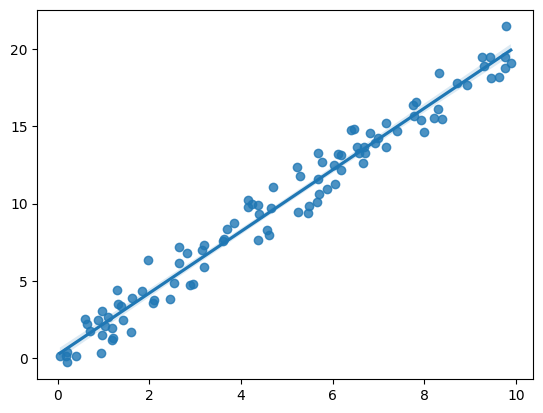

In [35]:
# 난수 생성 (재현 가능성 유지)
np.random.seed(0)
x = np.random.rand(100) * 10  # 0~10 사이 난수
y = 2 * x + np.random.randn(100)  # x와 비례하는 관계, 약간의 변동 추가

sns.regplot(x=x, y=y)

plt.show()

## 관계 데이터 - 미니 퀘스트

### 1번 퀘스트
Seaborn의 `scatterplot`을 활용하여 "총 결제 금액"(`total_bill`)과 "팁"(`tip`)의 관계를 시각화하는 코드를 작성하세요.

단, `scatterplot`의 색상과 스타일을 다르게 설정하여 출력해야 합니다.

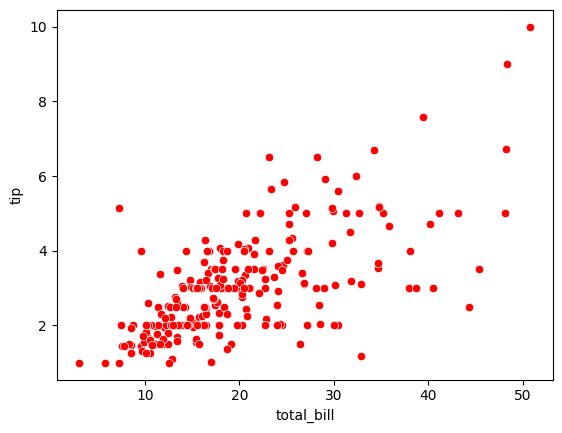

In [36]:
# 예제 데이터 로드 (Seaborn 내장 데이터셋: tips)
tips = sns.load_dataset("tips")

sns.scatterplot(x=tips["total_bill"], y=tips["tip"], color="red")

plt.show()

### 2번 퀘스트
`sns.regplot`을 사용하여 "총 결제 금액"(`total_bill`)과 "팁"(`tip`)의 관계를 나타내는 회귀선 그래프를 그리고, 산점도의 투명도를 조정하는 코드를 작성하세요.

**단, 산점도에서 특정 성별(`sex`)만 필터링하여 표시해야 합니다.**

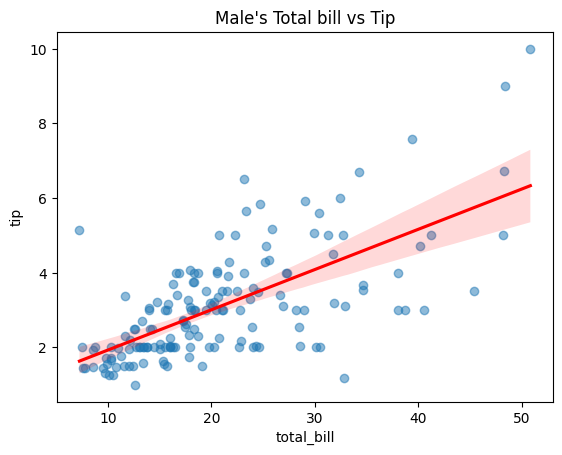

In [37]:
# 예제 데이터 로드
tips = sns.load_dataset("tips")

male_tips = tips[tips["sex"] == "Male"]
sns.regplot(x=male_tips["total_bill"], y=male_tips['tip'], scatter_kws={"alpha": .5}, line_kws={"color": "red"})

plt.title("Male's Total bill vs Tip")

plt.show()

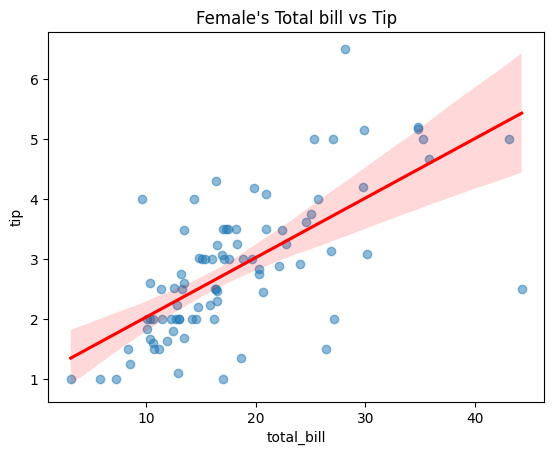

In [38]:
female_tips = tips[tips["sex"] == "Female"]
sns.regplot(x=female_tips["total_bill"], y=female_tips['tip'], scatter_kws={"alpha": .5}, line_kws={"color": "red"})

plt.title("Female's Total bill vs Tip")

plt.show()

### 3번 퀘스트
`sns.pairplot`을 사용하여 다중 변수(`total_bill`, `tip`, `size`) 간의 관계를 성별(`sex`)과 요일(`day`)에 따라 시각화하는 코드를 작성하세요.

단, 요일(`day`)에 따라 다른 색상을 적용해야 합니다.

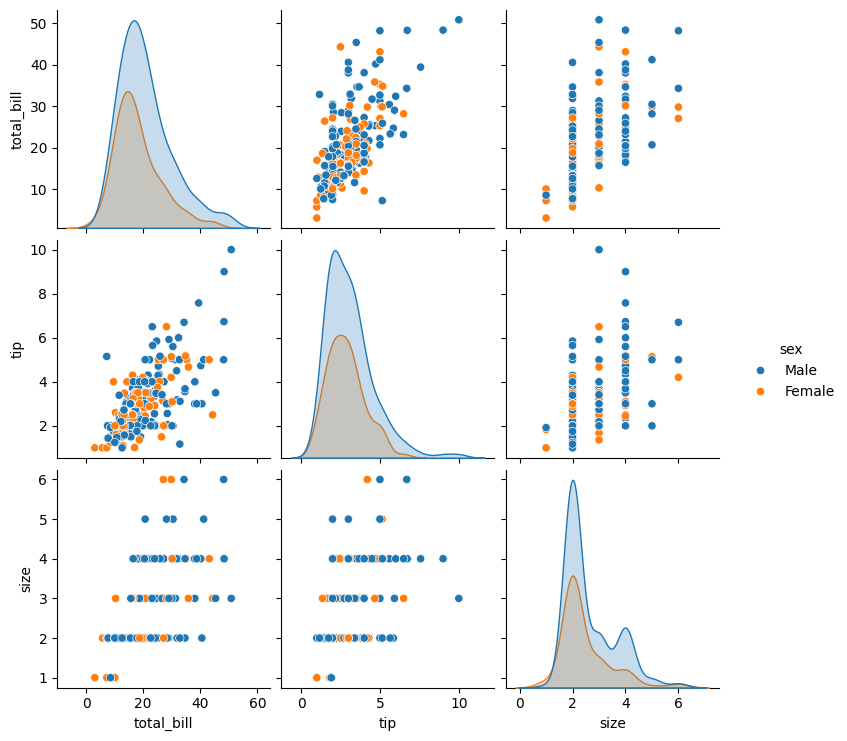

In [39]:
# 예제 데이터 로드
tips = sns.load_dataset("tips")

sns.pairplot(tips, vars=["total_bill", "tip", "size"], hue="sex")

plt.show()

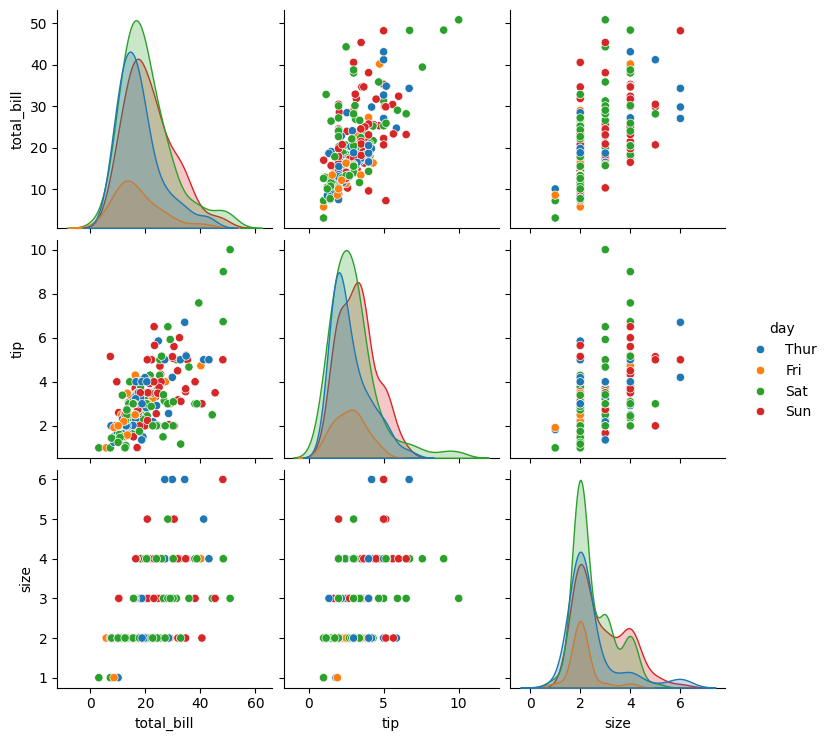

In [40]:
sns.pairplot(tips, vars=["total_bill", "tip", "size"], hue="day")

plt.show()

## 시계열 데이터 - 미니 퀘스트

### 1번 퀘스트
100일간의 시계열 데이터를 생성하고, 이를 선 그래프로 시각화하는 코드를 작성하세요.

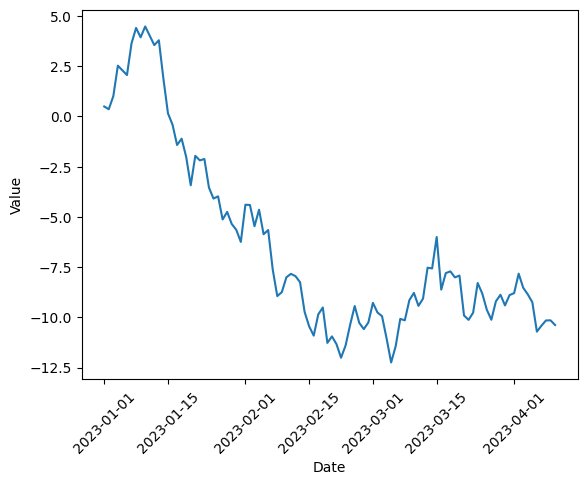

In [41]:
# 시계열 데이터 생성
np.random.seed(42)
date_range = pd.date_range(start="2023-01-01", periods=100, freq="D")  # 100일간의 날짜 생성
values = np.cumsum(np.random.randn(100))  # 랜덤 값의 누적합

df = pd.DataFrame({"Date": date_range, "Value": values})

sns.lineplot(df, x="Date", y="Value")

plt.xticks(rotation=45)

plt.show()

### 2번 퀘스트
1번 퀘스트에서 생성한 데이터를 기반으로 7일 이동 평균을 계산하고, 원본 데이터와 함께 그래프로 비교하는 코드를 작성하세요.

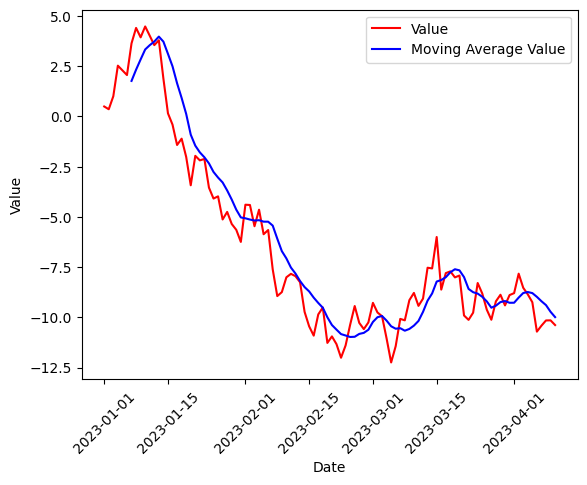

In [42]:
# 시계열 데이터 생성
np.random.seed(42)
date_range = pd.date_range(start="2023-01-01", periods=100, freq="D")
values = np.cumsum(np.random.randn(100))

df["Moving_Avg"] = df["Value"].rolling(window=7).mean()

sns.lineplot(df, x="Date", y="Value", color="red", label="Value")
sns.lineplot(df, x="Date", y="Moving_Avg", color="blue", label="Moving Average Value")

plt.xticks(rotation=45)
plt.legend()

plt.show()

### 3번 퀘스트
1번 퀘스트에서 생성한 시계열 데이터에서 이상치를 탐지하고, 이상치만 강조하여 그래프에 표시하는 코드를 작성하세요.

이상치는 사분위수 범위(IQR)를 이용해 판단합니다.

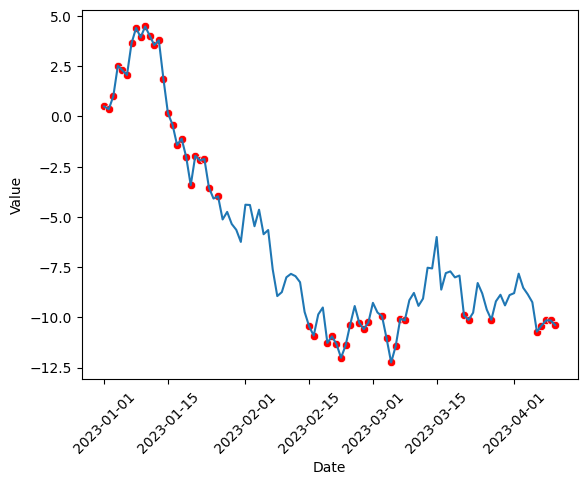

In [43]:
# 시계열 데이터 생성
np.random.seed(42)
date_range = pd.date_range(start="2023-01-01", periods=100, freq="D")
values = np.cumsum(np.random.randn(100))

Q1 = df["Value"].quantile(.25)
Q3 = df["Value"].quantile(.75)

df["Outlier"] = (df["Value"] < Q1) | (df["Value"] > Q3)
outliers = df[df["Outlier"]]

sns.lineplot(df, x="Date", y="Value")
sns.scatterplot(outliers, x="Date", y="Value", color="red")

plt.xticks(rotation=45)

plt.show()

## 리샘플링 - 미니 퀘스트

### 1번 퀘스트
`pandas`를 사용하여 **3시간 간격의 시계열 데이터를 생성한 후**, 하루 단위(`D`)로 **평균을 구하는 다운샘플링을 수행하는 코드**를 작성하세요.

In [44]:
# 3시간 간격의 시계열 데이터 생성 (2024년 1월 1일부터 5일까지)
date_rng = pd.date_range(start="2024-01-01", end="2024-01-05", freq="3h")

df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(0, 100, size=len(date_rng)) # 임의의 값
})
df.set_index("datetime", inplace=True)
df.resample("D").mean()

,value
datetime,
2024-01-01,49.375
2024-01-02,61.375
2024-01-03,30.750
2024-01-04,55.000
2024-01-05,1.000


### 2번 퀘스트
3시간 간격으로 생성된 시계열 데이터에서 1시간 단위로 업샘플링한 후, 선형 보간(linear)을 적용하는 코드를 작성하세요.

In [45]:
# 3시간 간격의 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-03", freq="3h")

df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(0, 100, size=len(date_rng)) # 임의의 값
})
df.set_index("datetime", inplace=True)
df_hourly = df.resample("h").asfreq()
df_linear_hourly = df_hourly.interpolate(method="linear")
df_linear_hourly

,value
datetime,
2024-01-01 00:00:00,52.000000
2024-01-01 01:00:00,49.000000
2024-01-01 02:00:00,46.000000
2024-01-01 03:00:00,43.000000
2024-01-01 04:00:00,58.333333
2024-01-01 05:00:00,73.666667
2024-01-01 06:00:00,89.000000
2024-01-01 07:00:00,69.666667
2024-01-01 08:00:00,50.333333


### 3번 퀘스트
3시간 간격으로 생성된 시계열 데이터에서 하루 단위(`D`)로 다운샘플링을 수행한 후, 각 날짜에 해당하는 최소(`min`) 값과 최대(`max`) 값을 출력하는 코드를 작성하세요.

In [46]:
# 3시간 간격의 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-07", freq="3h")

df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(0, 100, size=len(date_rng)) # 임의의 값
})
df.set_index("datetime", inplace=True)
df_hourly_min = df.resample("D").min()
df_hourly_max = df.resample("D").max()

print("[하루 단위 최솟값]")
df_hourly_min

[하루 단위 최솟값]


,value
datetime,
2024-01-01,10
2024-01-02,2
2024-01-03,19
2024-01-04,0
2024-01-05,1
2024-01-06,0
2024-01-07,18


In [47]:
print("[하루 단위 최댓값]")
df_hourly_max

[하루 단위 최댓값]


,value
datetime,
2024-01-01,96
2024-01-02,89
2024-01-03,95
2024-01-04,91
2024-01-05,98
2024-01-06,98
2024-01-07,18


## 이동평균 - 미니 퀘스트

### 1번 퀘스트
주어진 시계열 데이터에서 7일 단순 이동평균(SMA) 을 계산하여 새로운 컬럼을 추가하는 코드를 작성하세요.

In [48]:
# 샘플 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-20", freq="D")
df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(50, 150, size=len(date_rng))
})

df["sma"] = df["value"].rolling(window=7).mean()
df

,datetime,value,sma
0,2024-01-01,97,NaN
1,2024-01-02,129,NaN
2,2024-01-03,52,NaN
3,2024-01-04,69,NaN
4,2024-01-05,73,NaN
5,2024-01-06,103,NaN
6,2024-01-07,82,86.428571
7,2024-01-08,73,83.000000
8,2024-01-09,124,82.285714
9,2024-01-10,121,92.142857


### 2번 퀘스트
시계열 데이터에서 7일 지수 이동평균(EMA) 을 계산하고, 기존 데이터와 비교하여 출력하는 코드를 작성하세요.

In [49]:
# 샘플 시계열 데이터 생성
df["ema"] = df["value"].ewm(span=7).mean()
df

,datetime,value,sma,ema
0,2024-01-01,97,NaN,97.000000
1,2024-01-02,129,NaN,115.285714
2,2024-01-03,52,NaN,87.918919
3,2024-01-04,69,NaN,81.000000
4,2024-01-05,73,NaN,78.377721
5,2024-01-06,103,NaN,85.866053
6,2024-01-07,82,86.428571,84.750652
7,2024-01-08,73,83.000000,81.486172
8,2024-01-09,124,82.285714,92.977448
9,2024-01-10,121,92.142857,100.401140


### 3번 퀘스트
주어진 시계열 데이터에서 **이동평균을 활용하여 변동성이 큰 날을 탐색하는 코드**를 작성하세요.

**7일 단순 이동평균(SMA)과 비교하여 특정 일자의 값이 이동평균보다 ±20% 이상 차이가 나는 경우만 출력**하세요.

In [50]:
# 샘플 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-20", freq="D")
df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(50, 150, size=len(date_rng))
})

df['sma'] = df['value'].rolling(7).mean()
ratio = (df['value'] - df['sma']) / df['value']
df[(ratio > .2) | (ratio < -.2)]

,datetime,value,sma
6,2024-01-07,149,111.428571
7,2024-01-08,82,106.714286
9,2024-01-10,82,108.428571
10,2024-01-11,63,99.000000
11,2024-01-12,70,93.285714
13,2024-01-14,69,82.857143
14,2024-01-15,57,79.285714
15,2024-01-16,56,70.571429
16,2024-01-17,116,75.428571
19,2024-01-20,97,77.571429


## 금융 데이터 - 미니 퀘스트

### 1번 퀘스트
**샘플 금융 데이터프레임을 직접 생성한 후**, 데이터의 **기본 정보(행 개수, 열 개수, 데이터 타입 등)를 출력하는 코드**를 작성하세요.

In [51]:
# 샘플 금융 데이터 생성
data = {
    'Date': pd.date_range(start='2024-01-01', periods=10, freq='D'),
    'Open': [100, 102, 105, 103, 108, 107, 110, 112, 115, 118],
    'High': [102, 106, 108, 107, 110, 109, 112, 115, 117, 120],
    'Low': [98, 100, 103, 101, 106, 105, 108, 110, 113, 116],
    'Close': [101, 104, 106, 105, 109, 108, 111, 113, 116, 119],
    'Volume': [1000, 1200, 1500, 1300, 1600, 1400, 1700, 1800, 1900, 2000]
}

df = pd.DataFrame(data)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    10 non-null     datetime64[us]
 1   Open    10 non-null     int64         
 2   High    10 non-null     int64         
 3   Low     10 non-null     int64         
 4   Close   10 non-null     int64         
 5   Volume  10 non-null     int64         
dtypes: datetime64[us](1), int64(5)
memory usage: 612.0 bytes


### 2번 퀘스트
주어진 `df` 데이터프레임에서 **5일 이동평균(SMA)과 5일 지수 이동평균(EMA)을 계산하는 코드**를 작성하세요.

In [52]:
# 샘플 금융 데이터 생성
data = {
    'Date': pd.date_range(start='2024-01-01', periods=10, freq='D'),
    'Close': [101, 104, 106, 105, 109, 108, 111, 113, 116, 119]
}

df = pd.DataFrame(data)
df["SMA"] = df['Close'].rolling(5).mean()
df["EMA"] = df['Close'].ewm(5).mean()
df

,Date,Close,SMA,EMA
0,2024-01-01,101,NaN,101.000000
1,2024-01-02,104,NaN,102.636364
2,2024-01-03,106,NaN,103.967033
3,2024-01-04,105,NaN,104.299553
4,2024-01-05,109,105.0,105.609331
5,2024-01-06,108,106.4,106.208404
6,2024-01-07,111,107.8,107.316157
7,2024-01-08,113,109.2,108.550543
8,2024-01-09,116,111.4,110.090591
9,2024-01-10,119,113.4,111.861505


### 3번 퀘스트
`df` 데이터프레임에서 **주간(7일) 단위로 종가(Close) 평균을 리샘플링한 후**, 이를 바탕으로 **주간 변동성(표준편차)을 계산하는 코드**를 작성하세요.

In [53]:
# 샘플 금융 데이터 생성 (30일치)
date_rng = pd.date_range(start='2024-01-01', periods=30, freq='D')
close_prices = np.random.uniform(100, 200, size=len(date_rng))  # 100~200 사이의 랜덤 종가 생성

df = pd.DataFrame({
    "datetime": date_rng,
    "close_prices": close_prices
})
df.set_index("datetime", inplace=True)
df['close_prices'].resample("W").mean().std()

np.float64(11.736089402651631)

## 정규 분포 - 미니 퀘스트

### 1번 퀘스트
평균 `60`, 표준 편차 `15`를 갖는 정규 분포에서 500개의 데이터를 생성한 후, 데이터의 **기본 통계 정보(평균, 표준 편차, 최소값, 최대값)를 출력하는 코드**를 작성하세요.

In [54]:
# 평균 60, 표준 편차 15인 정규 분포에서 500개의 난수 생성
data = np.random.normal(loc=60, scale=15, size=500)

series = pd.Series(data)
series.describe()

count    500.000000
mean      60.004288
std       15.090635
min       11.380990
25%       49.580796
50%       60.116076
75%       69.844604
max      117.790972
dtype: float64

### 2번 퀘스트
평균 `50`, 표준 편차 `10`을 갖는 정규 분포에서 특정 값 `x=65`의 **확률 밀도 함수(PDF) 값을 계산하고 출력하는 코드**를 작성하세요.

In [55]:
stats.norm.pdf(65, loc=50, scale=10)

np.float64(0.012951759566589175)

### 3번 퀘스트
평균 `70`, 표준 편차 `8`을 갖는 정규 분포에서 **(1) 특정 값 `x=80` 이하일 확률을 CDF로 계산하고, (2) 상위 5%에 해당하는 점수를 PPF로 계산하여 출력하는 코드**를 작성하세요.

In [56]:
cdf = stats.norm.cdf(80, loc=70, scale=8)
ppf = stats.norm.ppf(.95, loc=70, scale=8)

print(f"특정 값 x=80 이하일 확률: {cdf:.4f}")

특정 값 x=80 이하일 확률: 0.8944


In [57]:
print(f"상위 5%에 해당하는 점수: {ppf:.4f}")

상위 5%에 해당하는 점수: 83.1588


## 기술 통계 - 미니 퀘스트

### 1번 퀘스트
**주어진 데이터에서 평균과 중앙값의 차이를 계산하는 코드**를 작성하세요.

In [58]:
# 샘플 데이터 생성
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)  # 평균 50, 표준편차 10인 정규 분포 데이터 생성
df = pd.DataFrame(data, columns=["value"])  # 데이터프레임 생성

print(f"평균 - 중앙값: {df["value"].mean() - df["value"].median():.4f}")

평균 - 중앙값: 0.2311


### 2번 퀘스트
**데이터에서 이상값(Outlier)을 찾아 제거한 후, 원래 데이터와 이상값 제거 후 데이터의 평균을 비교하는 코드**를 작성하세요.

이상값은 **IQR(사분위 범위)를 사용하여 탐지**하세요.

In [59]:
# 샘플 데이터 생성
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)  # 평균 50, 표준편차 10인 정규 분포 데이터 생성
df = pd.DataFrame(data, columns=["value"])  # 데이터프레임 생성

coef = 1.5
Q1 = df["value"].quantile(.25)
Q3 = df["value"].quantile(.75)
IQR = Q3 - Q1

lower_bound = Q1 - coef * IQR
upper_bound = Q3 + coef * IQR

indices = df[(df["value"] < lower_bound) | (df["value"] > upper_bound)].index
df_no_outlier = df.drop(indices)

print(f"이상치 제거 전의 평균: {df["value"].mean():.4f}")
print(f"이상치 제거 후의 평균: {df_no_outlier["value"].mean():.4f}")

이상치 제거 전의 평균: 48.9615
이상치 제거 후의 평균: 49.2157


### 3번 퀘스트
**데이터의 왜도(Skewness)와 첨도(Kurtosis)를 계산하여 데이터의 분포 특성을 분석하는 코드**를 작성하세요.

In [60]:
# 샘플 데이터 생성
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)  # 평균 50, 표준편차 10인 정규 분포 데이터 생성
df = pd.DataFrame(data, columns=["value"])  # 데이터프레임 생성

skew = stats.skew(df["value"]) # 왜도
kurtosis = stats.kurtosis(df["value"]) # 첨도

print(f"왜도: {skew:.4f}")
print(f"첨도: {kurtosis:.4f}")

왜도: -0.1753
첨도: -0.1554


In [61]:
print(f"상위 5%에 해당하는 점수: {ppf}")

상위 5%에 해당하는 점수: 83.15882901561177


## 가설 검정 - 미니 퀘스트

### 1번 퀘스트
**단일 표본 t-검정(One-Sample t-test)** 을 수행하여 샘플 데이터의 평균이 특정 값과 유의미한 차이가 있는지 검정하는 코드를 작성하세요.

(평균 `50`, 표준 편차 `5`를 따르는 정규 분포에서 30개의 데이터를 생성하고, 해당 데이터가 평균 `52`와 차이가 있는지 확인하세요.)

In [62]:
# 샘플 데이터 생성
np.random.seed(42)
sample_data = np.random.normal(loc=50, scale=5, size=30)  # 평균 50, 표준편차 5인 데이터 30개 생성

t_stat, p_val = stats.ttest_1samp(sample_data, popmean=32)
print(f"t 통계량: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

t 통계량: 20.7637
p-value: 0.0000


### 2번 퀘스트
**카이제곱 검정(Chi-Square Test)** 을 수행하여 관측된 데이터와 기대값이 유의미한 차이가 있는지 확인하는 코드를 작성하세요.

In [63]:
# 관측된 데이터 (Observed)
observed = np.array([50, 60, 90])
# 기대값 (Expected)
expected = np.array([66, 66, 66]) * (observed.sum() / np.sum([66, 66, 66]))

chi_stat, p_val = stats.chisquare(observed, expected)
print(f"chi 통계량: {chi_stat:.4f}")
print(f"p-value: {p_val:.4f}")

chi 통계량: 13.0000
p-value: 0.0015


### 3번 퀘스트
**분산 분석(ANOVA, Analysis of Variance)** 을 수행하여 여러 그룹의 평균이 서로 다른지 검정하는 코드를 작성하세요.

In [64]:
# 샘플 데이터 생성
np.random.seed(42)
group_1 = np.random.normal(loc=50, scale=10, size=30)  # 평균 50, 표준편차 10
group_2 = np.random.normal(loc=55, scale=10, size=30)  # 평균 55, 표준편차 10
group_3 = np.random.normal(loc=60, scale=10, size=30)  # 평균 60, 표준편차 10

f_stat, p_val = stats.f_oneway(group_1, group_2, group_3)
print(f"f 통계량: {f_stat:.4f}")
print(f"p-value: {p_val:.4f}")

f 통계량: 12.2095
p-value: 0.0000


## 통계적 시각화 - 미니 퀘스트

### 1번 퀘스트
NumPy를 사용하여 **평균 70, 표준편차 20을 따르는 정규 분포 데이터 1000개를 생성**한 후, Matplotlib을 활용하여 **박스플롯을 그리는 코드**를 작성하세요.

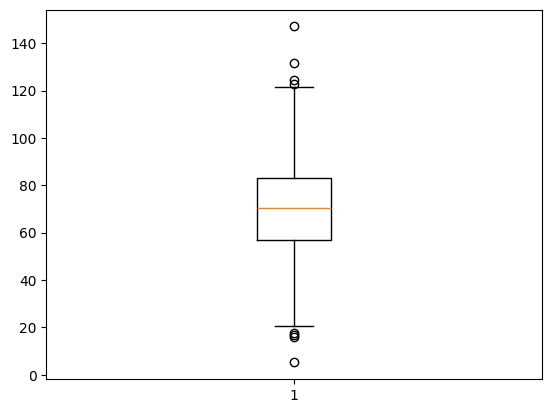

In [65]:
# 데이터 생성 (평균=70, 표준편차=20인 정규 분포 데이터 1000개)
np.random.seed(42)
data = np.random.normal(loc=70, scale=20, size=1000)

plt.boxplot(data)

plt.show()

### 2번 퀘스트
평균이 각각 55와 60이고, 표준편차가 8인 두 개의 그룹(A, B) 데이터를 생성한 후, **두 그룹의 데이터 분포를 Seaborn을 활용하여 KDE(커널 밀도 함수)와 함께 히스토그램으로 시각화**하세요.

이후, **두 그룹 간 평균 차이가 유의미한지 t-검정을 수행하는 코드**를 작성하세요.

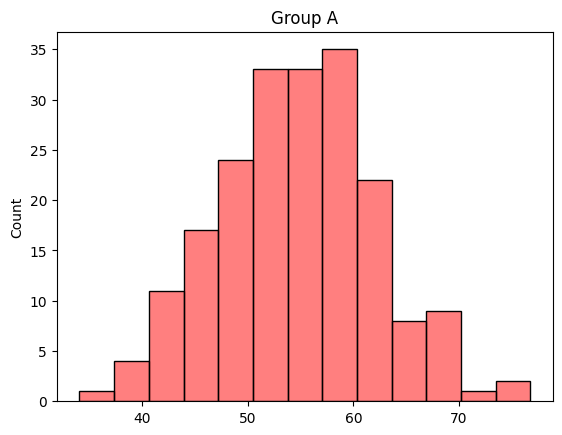

In [66]:
# 데이터 생성
np.random.seed(42)
group_A = np.random.normal(loc=55, scale=8, size=200)  # 평균 55, 표준편차 8
group_B = np.random.normal(loc=60, scale=8, size=200)  # 평균 60, 표준편차 8

sns.histplot(group_A, color="red", alpha=.5)

plt.title("Group A")

plt.show()

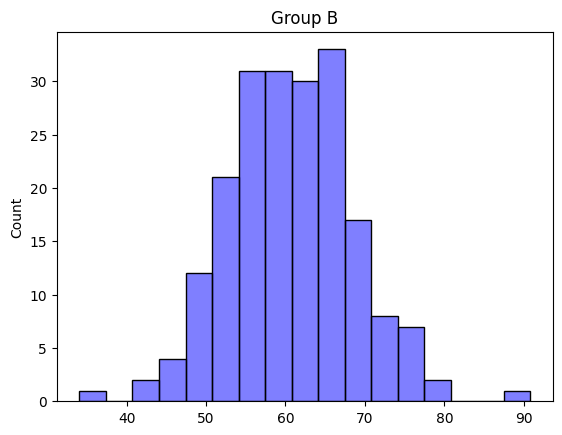

In [67]:
sns.histplot(group_B, color="blue", alpha=.5)

plt.title("Group B")

plt.show()

In [68]:
t_stat, p_val = stats.ttest_ind(group_A, group_B)

print(f"t stat: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}") # 통계적으로 유의함.

t stat: -7.8344
p-value: 0.0000


### 3번 퀘스트
광고 A를 본 500명 중 120명이 클릭하였고, 광고 B를 본 500명 중 150명이 클릭을 한 데이터가 있습니다.

이 데이터를 바탕으로 **카이제곱 검정을 수행하여 광고 A와 B의 클릭률 차이가 유의미한지 분석하고, Seaborn의 barplot을 사용하여 클릭률을 비교하는 그래프를 그리는 코드**를 작성하세요.

In [69]:
# 데이터 생성 (광고 A와 B의 클릭 여부)
observed_data = pd.DataFrame({
    "Ad_A": [120, 380],  # 광고 A 클릭(120명) vs 미클릭(380명)
    "Ad_B": [150, 350]   # 광고 B 클릭(150명) vs 미클릭(350명)
}, index=["Click", "No Click"])

chi2_stat, p_val, dof, expected = stats.chi2_contingency(observed_data)
print(f"chi stat: {chi2_stat:.4f}")
print(f"p-value: {p_val:.4f}") # 0.0389로 신뢰도 96% 통계적으로 유의함.

chi stat: 4.2669
p-value: 0.0389


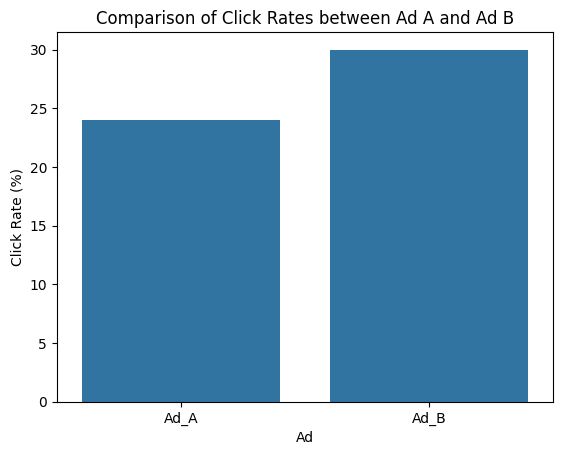

In [70]:
click_rates = pd.DataFrame({
    "Ad": ["Ad_A", "Ad_B"],
    "Click Rate (%)": [
        (observed_data.loc["Click", "Ad_A"] / observed_data["Ad_A"].sum()) * 100,
        (observed_data.loc["Click", "Ad_B"] / observed_data["Ad_B"].sum()) * 100
    ]
})

sns.barplot(x="Ad", y="Click Rate (%)", data=click_rates)
plt.title("Comparison of Click Rates between Ad A and Ad B")
plt.ylabel("Click Rate (%)")

plt.show()

## 위클리 챌린지 2-1: 시계열 데이터를 입수하여 시각화하세요.

seaborn 내장 `flights` 데이터셋(1949~1960년 월별 항공 탑승객 수)을 활용해 시계열을 시각화합니다.

In [71]:
flights = sns.load_dataset("flights")
flights["date"] = pd.to_datetime(flights["year"].astype(str) + "-" + flights["month"].astype(str))
flights = flights.sort_values("date")

flights.head()

/var/folders/ms/zdktjn0s1_g5c5ghs_kw8kxc0000gn/T/ipykernel_30327/2142868700.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flights["date"] = pd.to_datetime(flights["year"].astype(str) + "-" + flights["month"].astype(str))


,year,month,passengers,date
0,1949,Jan,112,1949-01-01
1,1949,Feb,118,1949-02-01
2,1949,Mar,132,1949-03-01
3,1949,Apr,129,1949-04-01
4,1949,May,121,1949-05-01


In [74]:
flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   year        144 non-null    int64         
 1   month       144 non-null    category      
 2   passengers  144 non-null    int64         
 3   date        144 non-null    datetime64[us]
dtypes: category(1), datetime64[us](1), int64(2)
memory usage: 4.0 KB


In [75]:
flights.describe()

,year,passengers,date
count,144.000000,144.000000,144
mean,1954.500000,280.298611,1954-12-16 05:00:00
min,1949.000000,104.000000,1949-01-01 00:00:00
25%,1951.750000,180.000000,1951-12-24 06:00:00
50%,1954.500000,265.500000,1954-12-16 12:00:00
75%,1957.250000,360.500000,1957-12-08 18:00:00
max,1960.000000,622.000000,1960-12-01 00:00:00
std,3.464102,119.966317,NaN


### 월별 항공 탑승객 수 추이

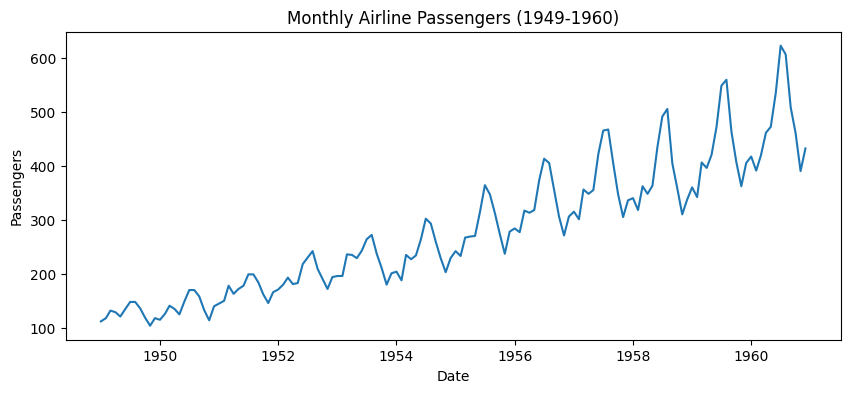

In [76]:
plt.figure(figsize=(10, 4))

plt.plot(flights["date"], flights["passengers"])

plt.title("Monthly Airline Passengers (1949-1960)")
plt.xlabel("Date")
plt.ylabel("Passengers")

plt.show()